In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

In [ ]:
blind = True
file1 = '../output/blind-metacal-updatedcov/des-y3-2pt-blind-metacal-simcov.txt'
file2 = '../output/blind-metacal-8arcmincut-december/des-y3-2pt-map3-all-blind-metacal.txt'
files = [file1, file2]
chains = utils.read_cosmosis_mcmc_des_blind_chains(files, to_mcsamples=True)
desy3_2ptonly, desy3_joint = chains[0], chains[1]

In [3]:
blind = False
desy3_joint = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-8arcmincut-december/des-y3-2pt-map3-all-blind-metacal.txt', to_mcsamples=True, blind=blind)

Removed no burn in


In [4]:
import numpy as np

# --- Step 1: Extract the best-fit sample from desy3_joint ---
# Assume desy3_joint.loglikes and desy3_joint.samples are available
best_idx = np.argmax(desy3_joint.loglikes)
best_sample = desy3_joint.samples[best_idx]  # NumPy array of best-fit parameter values

# Get the parameter names from the chain.
# (They are already strings; no need to access .name.)
param_names = list(desy3_joint.getParamNames().list())

# Build a dictionary from the chain parameter names to their best-fit values.
all_best_fit_params = dict(zip(param_names, best_sample))

# --- Step 2: Define a mapping from the required ini file parameter names to
# either the corresponding chain parameter name (if it exists) or a default value.
mapping = {
    # Cosmological parameters
    'omega_m': 'om',
    'h0': 'h0',
    'omega_b': 'ob',
    'n_s': 'ns',
    'S_8': 's8',
    'w': -1.0,  # default value since not in chain
    'num_massive_neutrinos': 'mnu',
    'nnu': 3.046,  # default value
    'omega_k': 0.0,  # default value
    'tau': 0.07,     # default value

    # Shear calibration parameters
    'm1': 'm1',
    'm2': 'm2',
    'm3': 'm3',
    'm4': 'm4',

    # Weak lensing photo-z errors
    'bias_1': 'dz1',
    'bias_2': 'dz2',
    'bias_3': 'dz3',
    'bias_4': 'dz4',

    # Intrinsic alignment parameters
    'z_piv': 0.62,  # default value
    'A1': 'a1',
    'alpha1': 'alpha1'
}

# --- Step 3: Build the best_fit_params dictionary using the mapping ---
best_fit_params = {}
for ini_key, source in mapping.items():
    if isinstance(source, str):
        # If 'source' is a string, use it as the key to look up the value in the chain.
        if source in all_best_fit_params:
            best_fit_params[ini_key] = all_best_fit_params[source]
        else:
            print(f"Warning: chain parameter '{source}' for '{ini_key}' not found; using None.")
            best_fit_params[ini_key] = None  # or choose another default
    else:
        # Otherwise, 'source' is already the default value.
        best_fit_params[ini_key] = source

# Optionally, print the resulting dictionary.
print("Best-fit parameters for ini file:")
for key, value in best_fit_params.items():
    print(f"{key}: {value}")

# Now you can pass best_fit_params to your ini file writer function.


Best-fit parameters for ini file:
omega_m: 0.31972273589610617
h0: 0.6215680140241409
omega_b: 0.031062035960954425
n_s: 0.9865908756093948
S_8: 0.7958829586631954
w: -1.0
num_massive_neutrinos: 0.5025060246102281
nnu: 3.046
omega_k: 0.0
tau: 0.07
m1: -0.01842323471515784
m2: -0.02595002294830238
m3: -0.02073400713853744
m4: -0.03325291775128107
bias_1: 0.018794716975230587
bias_2: -0.012071933045740479
bias_3: -0.00815373313452028
bias_4: 0.005518429109929456
z_piv: 0.62
A1: 1.28118309660716
alpha1: -0.5850111485032921


In [5]:
import configparser

def write_ini_file(best_fit_params, filename='best_fit_blindmetacal_8arcmincutdecember.ini'):
    """
    Write an ini file with sections and parameters based on the best-fit values.
    
    The ini file will have sections:
      - [cosmological_parameters]
      - [shear_calibration_parameters]
      - [wl_photoz_errors]
      - [intrinsic_alignment_parameters]
    
    For parameters whose ini entries are written as three numbers (e.g. "m1 = -0.1 0.0 0.1"),
    this code uses fixed minimum and maximum values (here, -0.1 and 0.1) and substitutes the
    central value by the one from best_fit_params.
    """
    config = configparser.ConfigParser()
    
    # If you want to preserve the case of keys exactly as you give them:
    config.optionxform = str
    
    # 1. Cosmological parameters
    config['cosmological_parameters'] = {
        'omega_m': str(best_fit_params.get('omega_m', 0.1)),
        'h0': str(best_fit_params.get('h0', 0.55)),
        'omega_b': str(best_fit_params.get('omega_b', 0.03)),
        'n_s': str(best_fit_params.get('n_s', 0.87)),
        'w': str(best_fit_params.get('w', -1.0)),
        'S_8': str(best_fit_params.get('S_8', 0.7)),
        'num_massive_neutrinos': '3',
        'nnu': str(best_fit_params.get('nnu', 3.046)),
        'omega_k': '0.0',
        'tau': '0.0697186'
    }
    
    # 2. Shear calibration parameters (here we keep the min and max fixed as in your example)
    config['shear_calibration_parameters'] = {
        'm1': f"-0.1 {best_fit_params.get('m1', 0.0)} 0.1",
        'm2': f"-0.1 {best_fit_params.get('m2', 0.0)} 0.1",
        'm3': f"-0.1 {best_fit_params.get('m3', 0.0)} 0.1",
        'm4': f"-0.1 {best_fit_params.get('m4', 0.0)} 0.1"
    }
    
    # 3. Weak lensing photo-z errors (again, keeping the min and max as in your example)
    config['wl_photoz_errors'] = {
        'bias_1': f"-0.1 {best_fit_params.get('bias_1', 0.0)} 0.1",
        'bias_2': f"-0.1 {best_fit_params.get('bias_2', 0.0)} 0.1",
        'bias_3': f"-0.1 {best_fit_params.get('bias_3', 0.0)} 0.1",
        'bias_4': f"-0.1 {best_fit_params.get('bias_4', 0.0)} 0.1"
    }
    
    # 4. Intrinsic alignment parameters
    config['intrinsic_alignment_parameters'] = {
        'z_piv': '0.62',
        'A1': f"-5.0 {best_fit_params.get('A1', 0.7)} 5.0",
        'alpha1': f"-5.0 {best_fit_params.get('alpha1', -1.7)} 5.0"
    }
    
    # Write the ini file
    with open(filename, 'w') as configfile:
        config.write(configfile)
    print(f"Ini file written to {filename}")
    
write_ini_file(best_fit_params)

Ini file written to best_fit_blindmetacal_8arcmincutdecember.ini


### Summary in one plot

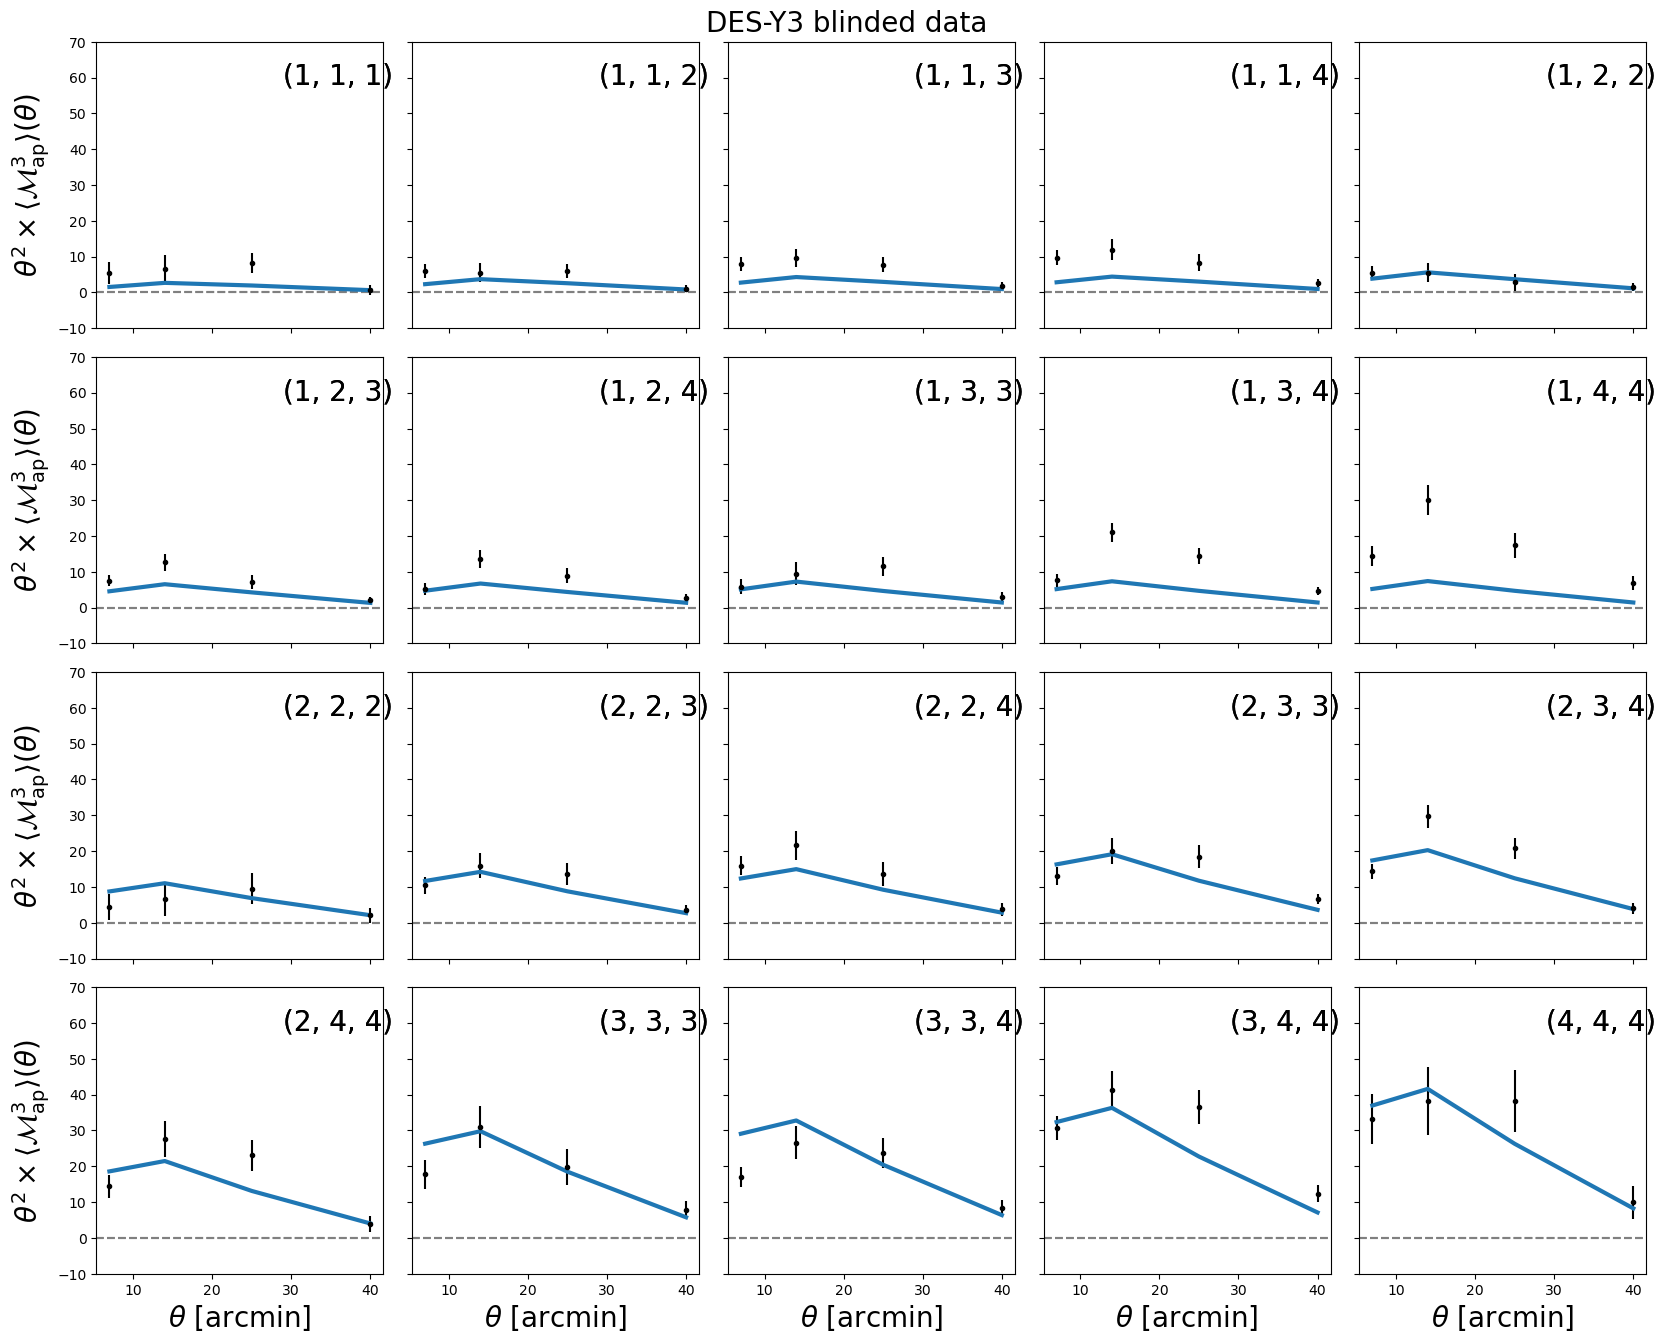

In [6]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/real_map3_desy3_blind_DECEMBER_8arcmincut.fits')
line_args = dict(color='k')
fig, axes = thpt.plot2d(4, 5, figsize=(20, 16), title='DES-Y3 blinded data', **line_args)
thpt_bf = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-emu-blindY3-BESTFIT-8arcmincut-december.fits')
line_args = dict(color='C0', lw=3)
fig, axes = thpt_bf.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args)
#fig.savefig('../plots/signal-blind-map3-vs-bestfit.pdf', bbox_inches='tight')

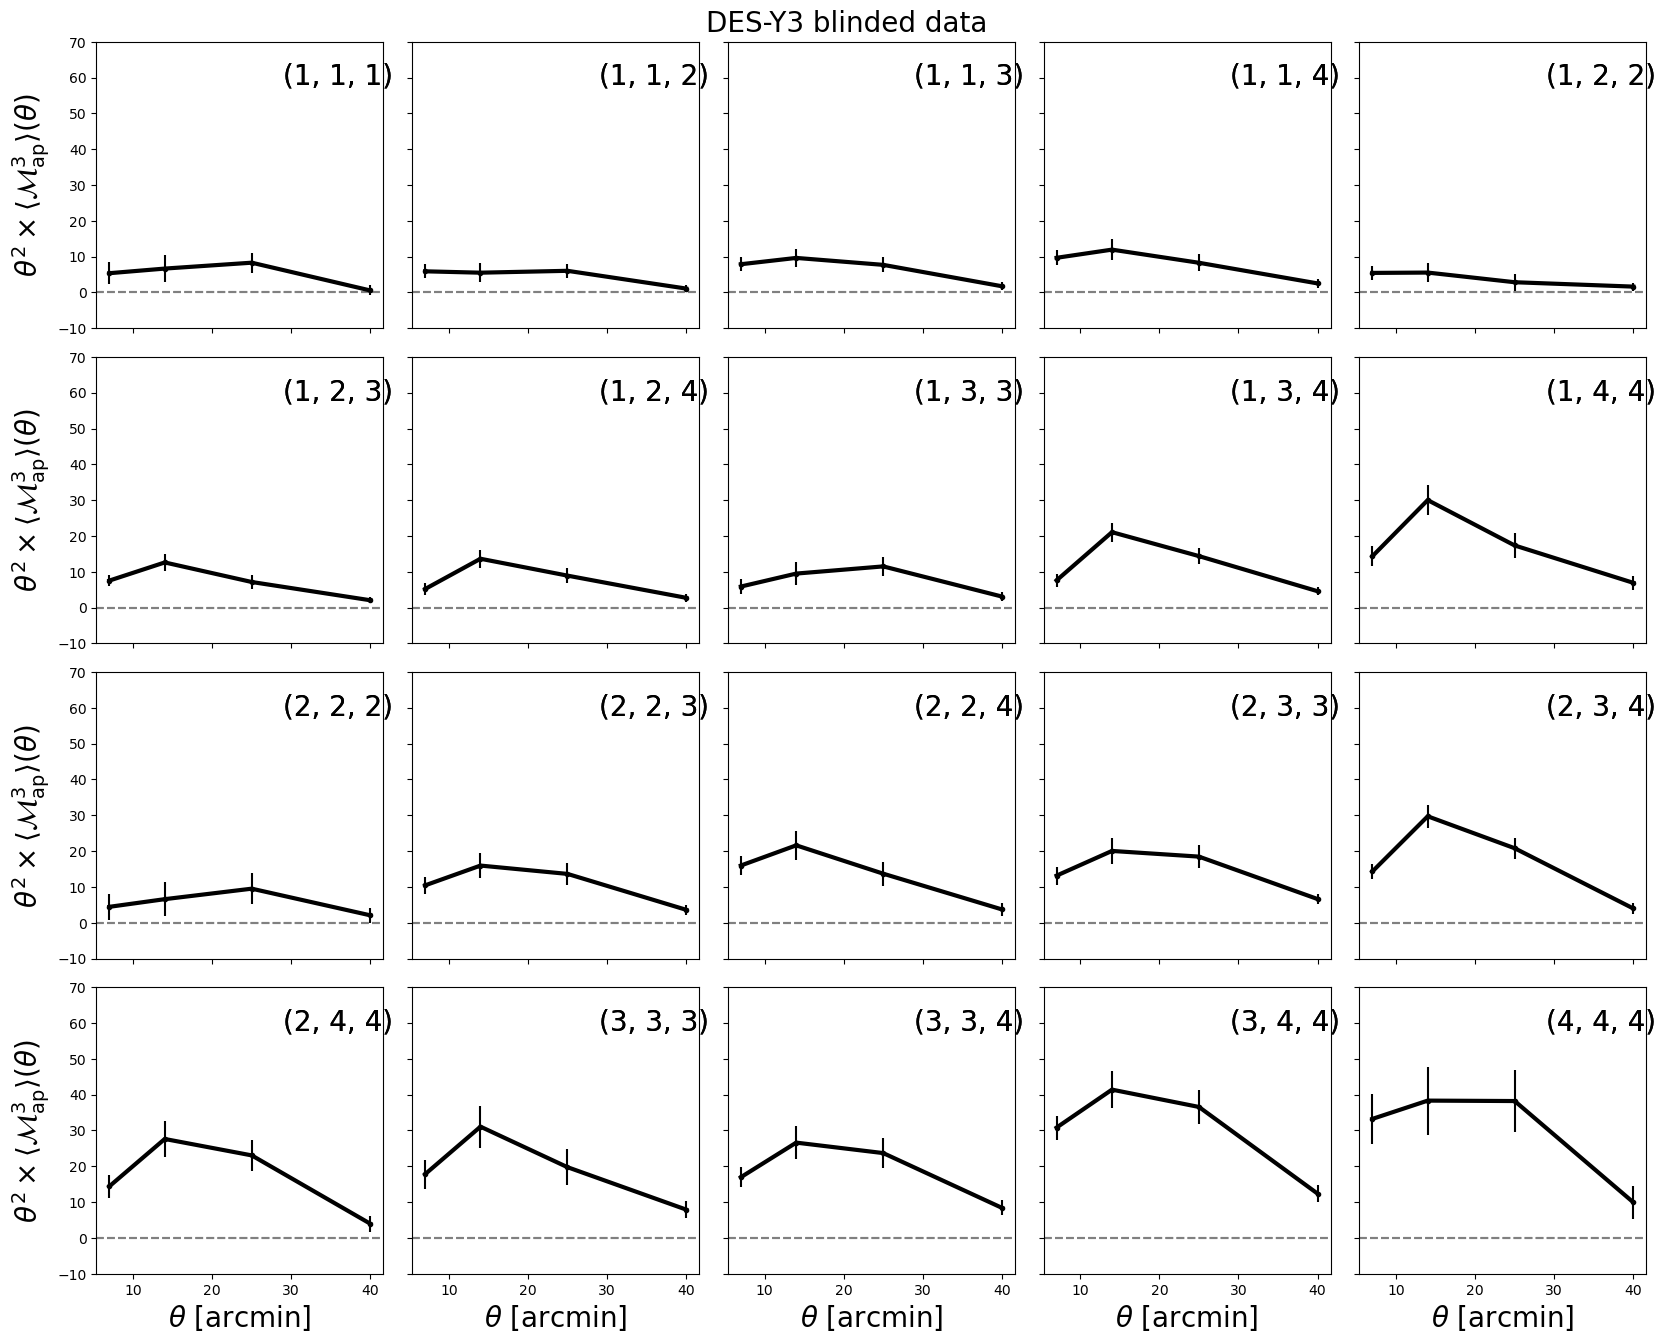

In [10]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/real_map3_desy3_blind_DECEMBER_8arcmincut.fits')
line_args = dict(color='k')
fig, axes = thpt.plot2d(4, 5, figsize=(20, 16), title='DES-Y3 blinded data', **line_args)
thpt_bf = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-emu-blindY3-BESTFIT-8arcmincut-december.fits')
line_args = dict(color='k', lw=3)
fig, axes = thpt.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args)
fig.savefig('../plots/signal-blind-map3-8arcmincut-december.pdf', bbox_inches='tight')